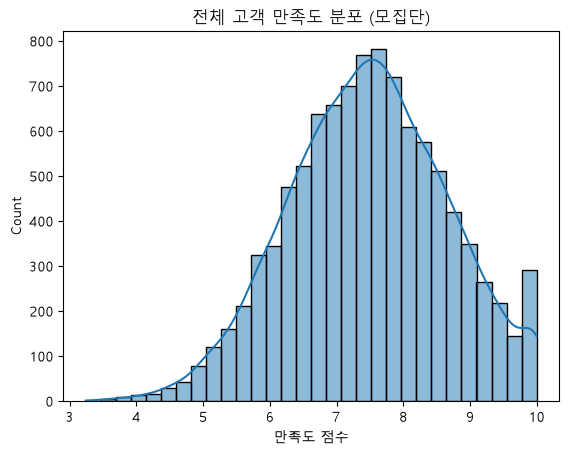

In [10]:
# 모집단 생성 (전체 고객 만족도 10,000명)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

In [20]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.

sample_1 = df_pop.sample(n = 30)


In [37]:
print(f"sample 1의 평균: {sample_1.mean().round(2)}")
print(f"df_pop의 평균: {df_pop.mean().round(2)}")

sample 1의 평균: score    7.45
dtype: float64
df_pop의 평균: score    7.48
dtype: float64


In [35]:
sample_mean = []   # 결과를 쌓아둘 빈 리스트

for i in range(500):
    sample_1 = df_pop.sample(n = 30)
    sample_500 = sample_1["score"].mean()
    sample_mean.append(sample_500)

print(f"총 {len(sample_mean)}개의 표본 평균이 저장되었습니다")
print(sample_mean[:5])   # 처음 5개만 확인

총 500개의 표본 평균이 저장되었습니다
[np.float64(7.305367842087565), np.float64(7.1460560785037215), np.float64(7.176004615754338), np.float64(7.242395018374406), np.float64(7.325996128871713)]


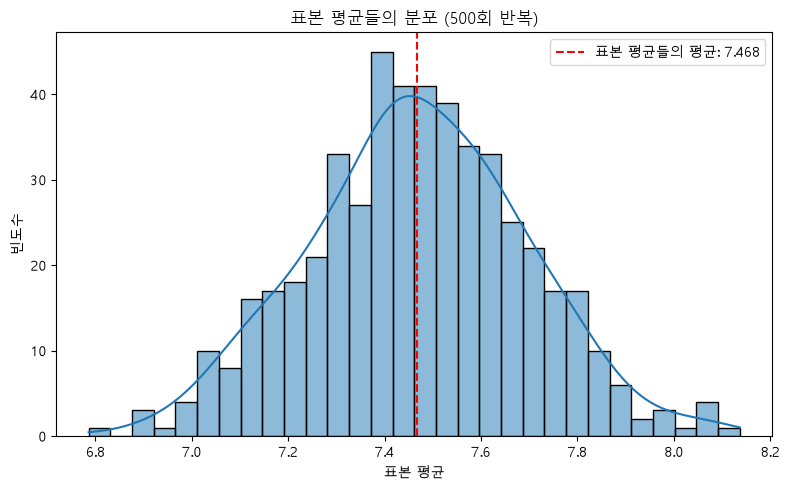

In [36]:
mean_of_means = np.mean(sample_mean)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(sample_mean, bins=30, kde=True, ax=ax)

ax.axvline(mean_of_means, color="red", linestyle="--", 
           label=f"표본 평균들의 평균: {mean_of_means:.3f}")   # 수정: mean_of_means로 통일

ax.set_title("표본 평균들의 분포 (500회 반복)")
ax.set_xlabel("표본 평균")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

🧠 데이터를 어떻게 읽을까요?
표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?
▸ 전체 모집단의 평균 7.48로 표본 평균 7.46과 매우 근접해있다.

표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요
▸ 횟수가 많으면 많을수록 표본 평균이 모평균에 근접한 양상을 보이게 되고(일치성) 신뢰성도 올라간다 (큰 수의 법칙)

친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?
▸ 표본의 경우 무작위로 500회 뽑기 때문에 내가 뽑았던 결과와 친구가 뽑은 표본이 비슷할지라도 그 결과는 일치하지 않는다.

표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?
▸ 표본의 크기가 작으면 정규분포처럼 보이지 않지만 어느정도 크기가 커진다면 표본의 평균은 정규분포처럼 보이게 된다(중심극한정리)

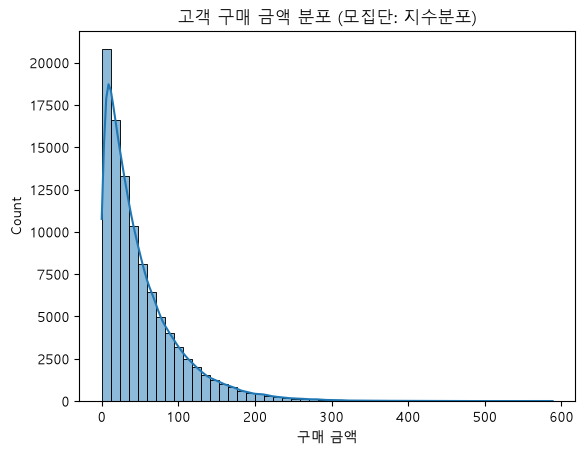

In [51]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

In [63]:
df_population = pd.DataFrame({"score": population})
population_5_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 5)
    population_1000 = population_sample["score"].mean()
    population_5_sample.append(population_1000)

print(f"총 {len(population_5_sample)}개의 표본 평균이 저장되었습니다")
print(population_5_sample[:5])   # 처음 5개만 확인

print(f"population 모집단 평균: {df_population.mean().round(2)}")
print(f"population 표본의 평균: {np.mean(population_5_sample):.2f}")

총 1000개의 표본 평균이 저장되었습니다
[np.float64(46.2478660365438), np.float64(53.475649685427435), np.float64(21.410317368343026), np.float64(33.04494584494485), np.float64(39.039108209954186)]
population 모집단 평균: score    50.23
dtype: float64
population 표본의 평균: 50.77


In [64]:
df_population = pd.DataFrame({"score": population})
population_30_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 30)
    population_1000 = population_sample["score"].mean()
    population_30_sample.append(population_1000)

print(f"총 {len(population_30_sample)}개의 표본 평균이 저장되었습니다")
print(population_30_sample[:5])   # 처음 5개만 확인

print(f"population 모집단 평균: {df_population.mean().round(2)}")
print(f"population 표본의 평균: {np.mean(population_30_sample):.2f}")

총 1000개의 표본 평균이 저장되었습니다
[np.float64(43.83827346021233), np.float64(47.63302103230357), np.float64(38.71214612969686), np.float64(76.28626010289041), np.float64(53.18301045520995)]
population 모집단 평균: score    50.23
dtype: float64
population 표본의 평균: 50.44


In [65]:
df_population = pd.DataFrame({"score": population})
population_100_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 100)
    population_1000 = population_sample["score"].mean()
    population_100_sample.append(population_1000)

print(f"총 {len(population_100_sample)}개의 표본 평균이 저장되었습니다")
print(population_100_sample[:5])   # 처음 5개만 확인

print(f"population 모집단 평균: {df_population.mean().round(2)}")
print(f"population 표본의 평균: {np.mean(population_100_sample):.2f}")

총 1000개의 표본 평균이 저장되었습니다
[np.float64(46.476465786231955), np.float64(54.84470595784091), np.float64(50.59794070884227), np.float64(51.116927805050175), np.float64(53.22648229917604)]
population 모집단 평균: score    50.23
dtype: float64
population 표본의 평균: 50.43


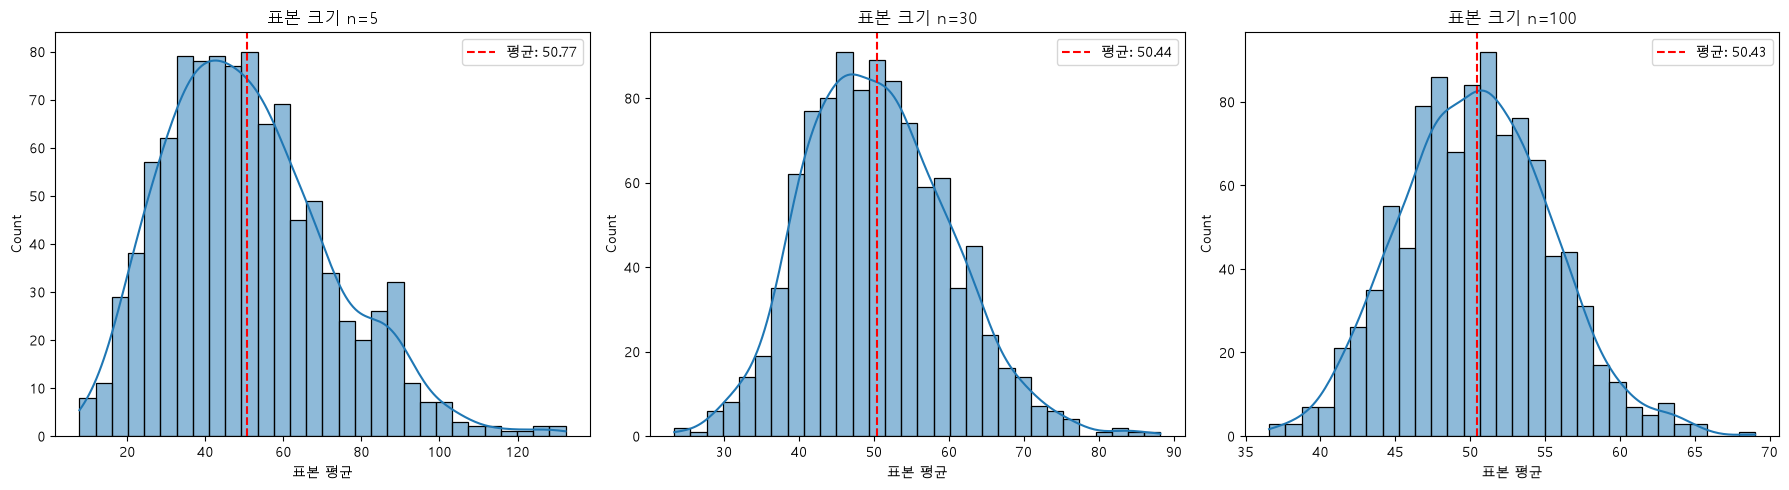

In [66]:
samples = {
    "n=5": population_5_sample,
    "n=30": population_30_sample,
    "n=100": population_100_sample
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, data) in zip(axes, samples.items()):
    mean_val = np.mean(data)
    sns.histplot(data, bins=30, kde=True, ax=ax)
    ax.axvline(mean_val, color="red", linestyle="--", label=f"평균: {mean_val:.2f}")
    ax.set_title(f"표본 크기 {name}")
    ax.set_xlabel("표본 평균")
    ax.legend()

plt.tight_layout()
plt.show()

🧠 데이터를 어떻게 읽을까요?

표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?
▸ 평균의 분포는 오른쪽으로 치우치도록 나옴.
표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?
▸ 표본의 크기가 커질수록 평균 분포는 정규 분포의 모양으로 변화함.
원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?
▸ 모집단이 비대칭이여도 표본의 크기가 커질수록 표본의 평균은 정규분포의 모양으로 가까워지는 중심극한정리 현상이 발생한다.
이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?
▸ 표본이 어느정도 크기가 커진다면 그 표본의 평균은 정규분포에 가까워진다.
표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?
▸ 표본의 크키가 커질숡 분포의 넓이는 좁아진다.

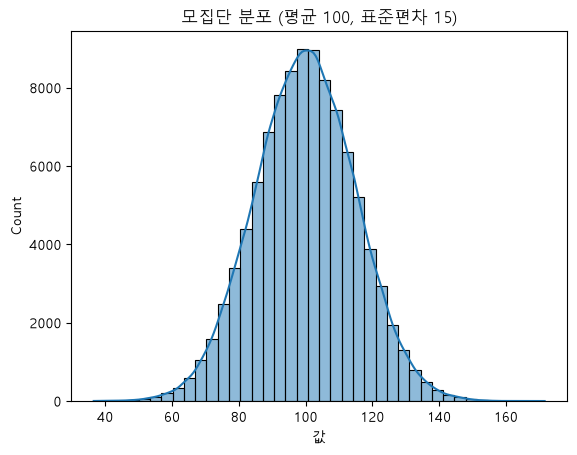

In [67]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

In [ ]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
df_population = pd.DataFrame({"score": population})
population_10_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 10)
    population_10 = population_sample["score"].mean()
    population_10_sample.append(population_10)


print(f"population 모집단 평균: {df_population.mean().round(2)}")
print(f"population 표본의 평균: {np.mean(population_10_sample):.2f}")

###########################################################################
df_population = pd.DataFrame({"score": population})
population_30_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 30)
    population_30 = population_sample["score"].mean()
    population_30_sample.append(population_30)

print(f"population 표본의 평균: {np.mean(population_30_sample):.2f}")
###########################################################################

df_population = pd.DataFrame({"score": population})
population_100_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 100)
    population_100 = population_sample["score"].mean()
    population_100_sample.append(population_100)

print(f"population 표본의 평균: {np.mean(population_100_sample):.2f}")
###########################################################################
df_population = pd.DataFrame({"score": population})
population_500_sample = []   # 결과를 쌓아둘 빈 리스트

for i in range(1000):
    population_sample = df_population.sample(n = 500)
    population_500 = population_sample["score"].mean()
    population_500_sample.append(population_500)

print(f"population 표본의 평균: {np.mean(population_500_sample):.2f}")
###########################################################################


# 여기에 코드를 작성해주세요.

population 모집단 평균: score    99.95
dtype: float64
population 표본의 평균: 99.77
population 표본의 평균: 99.83
population 표본의 평균: 99.92
population 표본의 평균: 99.96


In [ ]:
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

result = pd.DataFrame({
    '표본크기(n)': [10, 30, 100, 500],
    '표준편차': [
        np.std(population_10_sample, ddof=1),
        np.std(population_30_sample, ddof=1),
        np.std(population_100_sample, ddof=1),
        np.std(population_500_sample, ddof=1)
    ]
})
print(result)

   표본크기(n)      표준편차
0       10  4.819592
1       30  2.756994
2      100  1.594136
3      500  0.672001


In [72]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 여기에 코드를 작성해주세요.

import numpy as np

# 모집단 표준편차 (population 전체 데이터의 std)
population_std = np.std(population, ddof=0)  # 모집단은 보통 ddof=0

# 표본크기별 이론적 표준오차 계산
n_list = [10, 30, 100, 500]

for n in n_list:
    theoretical_se = population_std / np.sqrt(n)
    print(f"n={n} 이론적 표준오차(SE): {theoretical_se:.4f}")

n=10 이론적 표준오차(SE): 4.7539
n=30 이론적 표준오차(SE): 2.7447
n=100 이론적 표준오차(SE): 1.5033
n=500 이론적 표준오차(SE): 0.6723


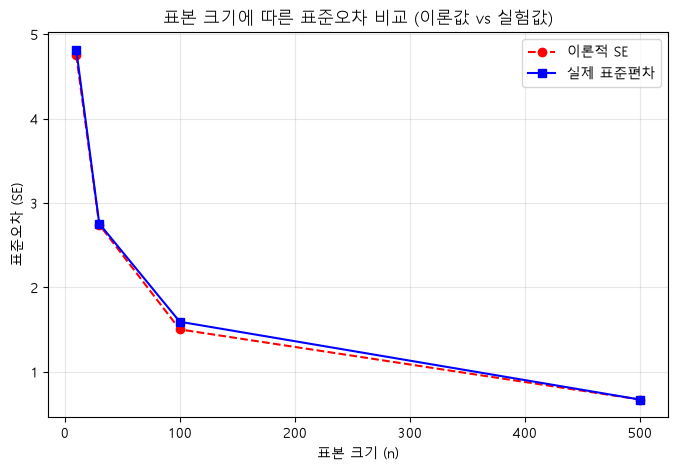

In [73]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 여기에 코드를 작성해주세요.
import numpy as np
import matplotlib.pyplot as plt

n_list = [10, 30, 100, 500]

samples = {
    10: population_10_sample,
    30: population_30_sample,
    100: population_100_sample,
    500: population_500_sample
}

# 이론적 SE와 실제 표준편차 계산
theoretical_se = [population_std / np.sqrt(n) for n in n_list]
actual_std = [np.std(samples[n], ddof=1) for n in n_list]

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(n_list, theoretical_se, marker='o', linestyle='--', label='이론적 SE', color='red')
plt.plot(n_list, actual_std, marker='s', linestyle='-', label='실제 표준편차', color='blue')

plt.title('표본 크기에 따른 표준오차 비교 (이론값 vs 실험값)')
plt.xlabel('표본 크기 (n)')
plt.ylabel('표준오차 (SE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

🧠 데이터를 어떻게 읽을까요?

표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?
▸ 표본 크기가 작을수록 표본 평균의 분포는 넓게 퍼져있다.
표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?
▸ 평균 분포는 정규분포로 변하면서 분포도 좁아진다.
실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?
▸ 매우 흡사하게 나왔습니다.
왜 표본 크기가 커질수록 표준오차는 작아질까요?
▸ 표본의 크기가 커질수록 표준오차의 분모인 n이 커지기 때문에 전체 값이 SE는 작아지게 된다. SE = σ / √n

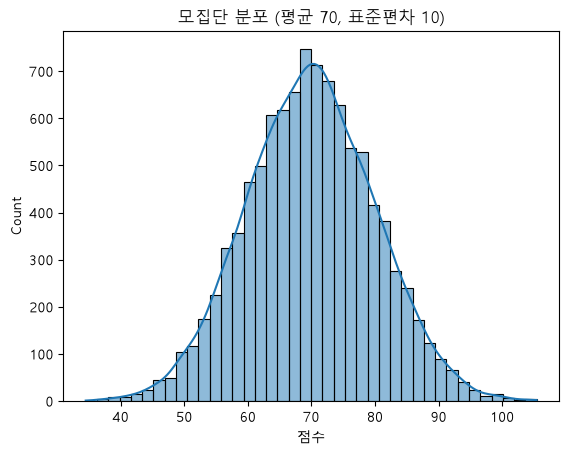

In [74]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

In [82]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.
df_population = pd.DataFrame({"score" : population})
population_30_sample = []

population_sample =df_population.sample(n = 30)
population_30 = population_sample["score"].mean()
population_30_sample.append(population_30)

print(f"population 표본 30의 평균: {population_sample.mean()}")
sample_std = np.std(population_sample, ddof=1)

# 3. 표준오차 (SE = 표본표준편차 / √n)
n = len(population_sample)
sample_se = sample_std / np.sqrt(n)

print(f"표본표준편차: {sample_std:.4f}")
print(f"표본크기: {n}")
print(f"표준오차(SE): {sample_se:.4f}")


population 표본 30의 평균: score    69.587835
dtype: float64
표본표준편차: 9.6921
표본크기: 30
표준오차(SE): 1.7695


In [84]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
from scipy import stats

n = len(population_sample)
sample_mean = np.mean(population_sample)

# 모집단 표준편차 (이미 알고 있다고 가정 - population에서 계산)
population_std = np.std(population, ddof=0)  # 모집단은 ddof=0

# 표준오차 계산
se = population_std / np.sqrt(n)

# 95% 신뢰구간에 해당하는 z값
z = stats.norm.ppf(0.975)  # 약 1.96

# 신뢰구간 계산
lower = sample_mean - z * se
upper = sample_mean + z * se

print(f"모집단 표준편차: {population_std:.4f}")
print(f"표본평균: {sample_mean:.4f}")
print(f"표본크기: {n}")
print(f"표준오차: {se:.4f}")
print(f"z값: {z:.4f}")
print(f"95% 신뢰구간: ({lower:.4f}, {upper:.4f})")


모집단 표준편차: 10.0051
표본평균: 69.5878
표본크기: 30
표준오차: 1.8267
z값: 1.9600
95% 신뢰구간: (66.0076, 73.1680)


In [85]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
n = len(population_sample)
sample_mean = np.mean(population_sample)
sample_std = np.std(population_sample, ddof=1)  # 표본표준편차 (n-1로 나눔)

# 표준오차 계산 (모표준편차를 모르니 표본표준편차 사용)
se = sample_std / np.sqrt(n)

# 자유도(degrees of freedom)
df = n - 1

# 95% 신뢰구간에 해당하는 t값
t_value = stats.t.ppf(0.975, df)

# 신뢰구간 계산
lower = sample_mean - t_value * se
upper = sample_mean + t_value * se

print(f"표본평균: {sample_mean:.4f}")
print(f"표본표준편차: {sample_std:.4f}")
print(f"표본크기: {n}, 자유도: {df}")
print(f"t값: {t_value:.4f}")
print(f"95% 신뢰구간: ({lower:.4f}, {upper:.4f})")

표본평균: 69.5878
표본표준편차: 9.6921
표본크기: 30, 자유도: 29
t값: 2.0452
95% 신뢰구간: (65.9687, 73.2069)


In [86]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

n = len(population_sample)
sample_mean = np.mean(population_sample)
sample_std = np.std(population_sample, ddof=1)
se = sample_std / np.sqrt(n)
df = n - 1

confidence_levels = [0.90, 0.95, 0.99]

print(f"{'신뢰수준':<10}{'t값':<10}{'하한':<12}{'상한':<12}{'폭':<10}")
for conf in confidence_levels:
    t_value = stats.t.ppf((1 + conf) / 2, df)
    lower = sample_mean - t_value * se
    upper = sample_mean + t_value * se
    width = upper - lower
    print(f"{conf*100:.0f}%{'':<6}{t_value:<10.4f}{lower:<12.4f}{upper:<12.4f}{width:<10.4f}")


신뢰수준      t값        하한          상한          폭         
90%      1.6991    66.5812     72.5945     6.0133    
95%      2.0452    65.9687     73.2069     7.2382    
99%      2.7564    64.7103     74.4654     9.7550    


🧠 데이터를 어떻게 읽을까요?
z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?
▸ 95% 신뢰수준의 z분포와 t분포 모두 비슷하게 나왔다. z값: 1.9600, t값: 2.0452
신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?
▸ 신뢰 수준이 높아질수록 신뢰구간의 폭은 넓어진다. 하한과 상한의 값이 그만큼 낮아지고 높아지기 때문에 그 폭도 넓어진다.
신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?
▸ 신뢰수준이 높을수록 폭이 넓어지고 더 안전하게 평가할 수 있어 신뢰수준이 낮은 쪽 보다는 안전하고 신뢰 수준이 낮을수록 폭이 좁아져 데이터의 정밀도는 높아진다.
이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?
▸ 신뢰수준 90%의 경우 폭이 그만큼 좁기 때문에 고객 만족도 평가 시 의사결정에 도움을 줄 수 있다.